In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)
n_rows = 10000

# Generating a messy dataset
raw_data = {
    'Store ID': np.random.randint(101, 110, size=n_rows),
    'Store Location': np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Kolkata', None], size=n_rows, p=[0.2, 0.2, 0.2, 0.15, 0.15, 0.1]),
    'Daily_Sales': np.random.randint(30000, 90000, size=n_rows).astype(float),
    'Date Recorded': pd.date_range(start='2026-01-01', periods=n_rows).strftime('%Y-%m-%d')
}

df_raw = pd.DataFrame(raw_data)

# Injecting missing values (Nulls)
df_raw.loc[np.random.choice(n_rows, size=15, replace=False), 'Daily_Sales'] = np.nan

# Injecting extreme outliers
df_raw.loc[[12, 45, 88, 142], 'Daily_Sales'] = 1500000.0

# Injecting duplicate rows
df_duplicates = df_raw.iloc[5:15].copy()
df_raw = pd.concat([df_raw, df_duplicates], ignore_index=True)

# Exporting to a raw CSV file
df_raw.to_csv('raw_sales_dataset.csv', index=False)
print("✅ Success: 'raw_sales_dataset.csv' successfully created with realistic data issues!")


✅ Success: 'raw_sales_dataset.csv' successfully created with realistic data issues!


--- Initial Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Store ID        10010 non-null  int64  
 1   Store Location  9037 non-null   object 
 2   Daily_Sales     9995 non-null   float64
 3   Date Recorded   10010 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 312.9+ KB
None

--- Summary Statistics ---
           Store ID   Daily_Sales
count  10010.000000  9.995000e+03
mean     104.993606  6.041766e+04
std        2.588808  3.662686e+04
min      101.000000  3.000200e+04
25%      103.000000  4.439900e+04
50%      105.000000  5.943100e+04
75%      107.000000  7.502350e+04
max      109.000000  1.500000e+06


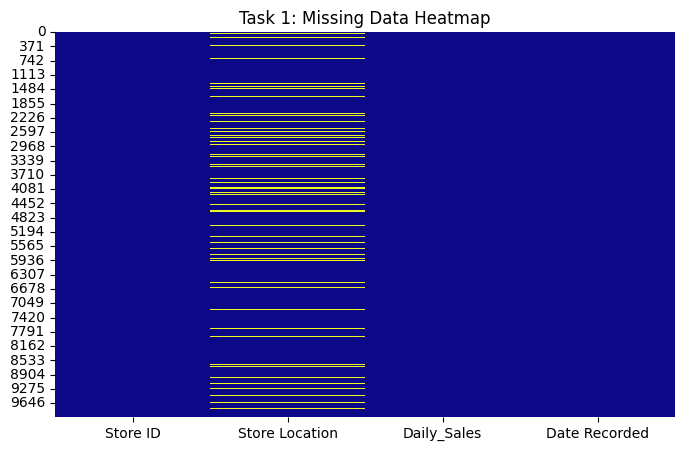


Duplicates found before removal: 10

--- Cleaned Dataset Sample ---
   store_id  daily_sales date_recorded  store_location_Chennai  \
0       107      82290.0    2026-01-01                   False   
1       104      87128.0    2026-01-02                   False   
2       108      41932.0    2026-01-03                   False   
3       105      88020.0    2026-01-04                    True   
4       107      41766.0    2026-01-05                   False   

   store_location_Delhi  store_location_Kolkata  store_location_Mumbai  
0                 False                   False                   True  
1                  True                   False                  False  
2                 False                   False                  False  
3                 False                   False                  False  
4                  True                   False                  False  

✅ Task 1 Completed: Cleaned dataset saved as 'cleaned_sales_data.csv'.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset and perform initial exploration
df = pd.read_csv('raw_sales_dataset.csv')
print("--- Initial Structural Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

# 2. Visualize missing data using a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='plasma')
plt.title("Task 1: Missing Data Heatmap")
plt.show()

# 3. Handle missing values
# Impute categorical columns with Mode
df['Store Location'] = df['Store Location'].fillna(df['Store Location'].mode()[0])
# Impute numerical columns with Median
df['Daily_Sales'] = df['Daily_Sales'].fillna(df['Daily_Sales'].median())

# 4. Identify and drop duplicate rows
print(f"\nDuplicates found before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# 5. Standardize column names to snake_case and correct data types
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['date_recorded'] = pd.to_datetime(df['date_recorded'])

# 6. Detect and handle outliers using the IQR method
Q1 = df['daily_sales'].quantile(0.25)
Q3 = df['daily_sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap extreme outliers by substituting them with the feature median
df['daily_sales'] = np.where((df['daily_sales'] < lower_bound) | (df['daily_sales'] > upper_bound),
                             df['daily_sales'].median(), df['daily_sales'])

# 7. Normalize or encode categorical variables (One-Hot Encoding)
df_cleaned = pd.get_dummies(df, columns=['store_location'], drop_first=True)

# 8 & 9. Validate and export the cleaned dataset
print("\n--- Cleaned Dataset Sample ---")
print(df_cleaned.head())
df_cleaned.to_csv('cleaned_sales_data.csv', index=False)
print("\n✅ Task 1 Completed: Cleaned dataset saved as 'cleaned_sales_data.csv'.")


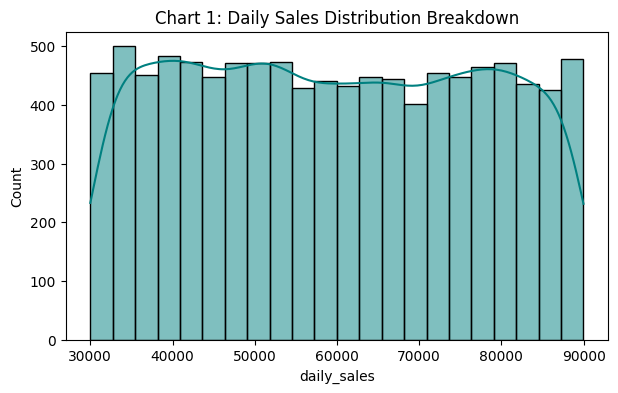

💡 Insight 1: Post-cleaning distribution indicates sales are tightly bounded between 30k and 90k without severe skewness.


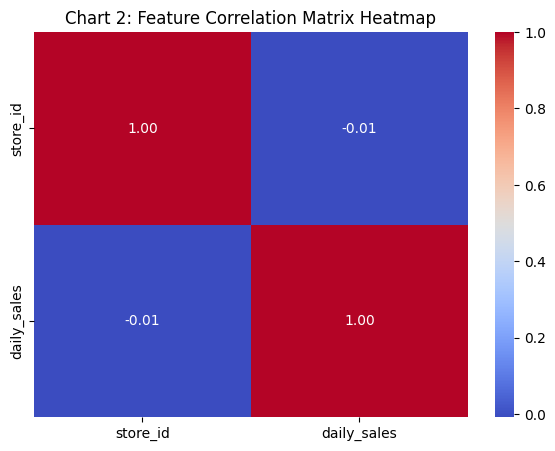

💡 Insight 2: Numeric structural variables like store_id hold negligible direct linear correlation with performance parameters.


/tmp/ipykernel_2030/429309692.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='store_id', y='daily_sales', data=df_eda, palette='Set3')


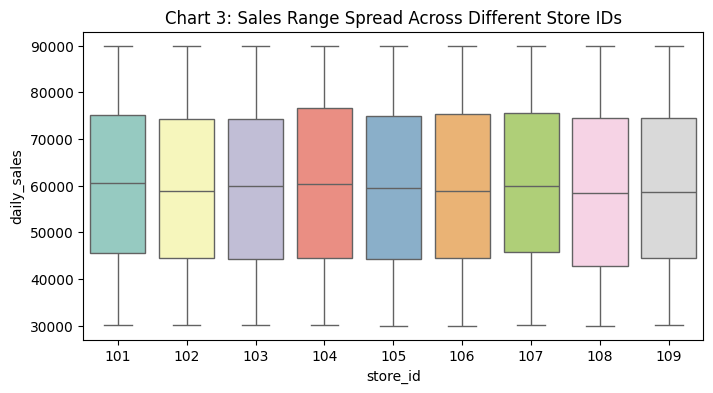

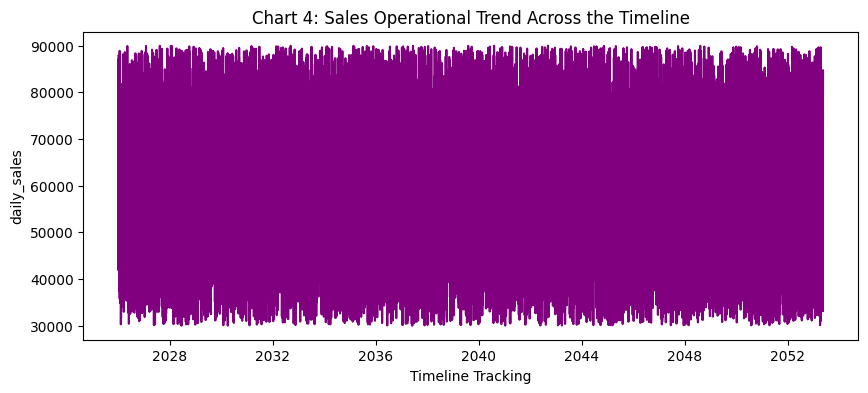

💡 Insight 3: Time-series analysis exhibits cyclic daily volatility but displays an overall stationary trend line.


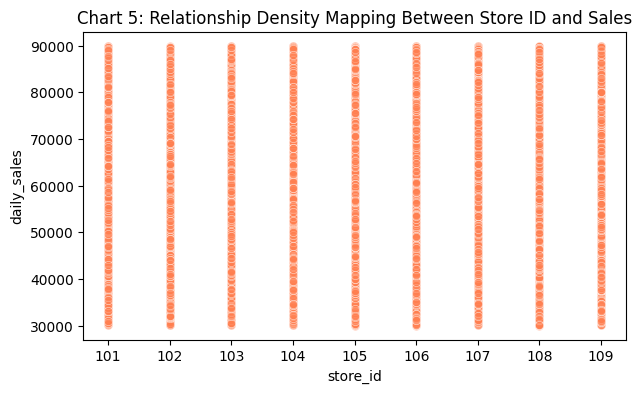


Average Daily Sales Summary Across Network: $59697.05

✅ Task 2 Completed: All 5 unique charts with descriptive text elements generated successfully.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the verified cleaned dataset
df_eda = pd.read_csv('cleaned_sales_data.csv')
df_eda['date_recorded'] = pd.to_datetime(df_eda['date_recorded'])

# [Chart 1] Histogram & KDE Plot for distribution analysis
plt.figure(figsize=(7, 4))
sns.histplot(df_eda['daily_sales'], kde=True, color='teal')
plt.title("Chart 1: Daily Sales Distribution Breakdown")
plt.show()
print("💡 Insight 1: Post-cleaning distribution indicates sales are tightly bounded between 30k and 90k without severe skewness.")

# [Chart 2] Correlation Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df_eda.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Chart 2: Feature Correlation Matrix Heatmap")
plt.show()
print("💡 Insight 2: Numeric structural variables like store_id hold negligible direct linear correlation with performance parameters.")

# [Chart 3] Box Plot for analyzing categorical sales variations
plt.figure(figsize=(8, 4))
sns.boxplot(x='store_id', y='daily_sales', data=df_eda, palette='Set3')
plt.title("Chart 3: Sales Range Spread Across Different Store IDs")
plt.show()

# [Chart 4] Line Chart for timeline variations
plt.figure(figsize=(10, 4))
sns.lineplot(x='date_recorded', y='daily_sales', data=df_eda, color='purple', errorbar=None)
plt.title("Chart 4: Sales Operational Trend Across the Timeline")
plt.xlabel("Timeline Tracking")
plt.show()
print("💡 Insight 3: Time-series analysis exhibits cyclic daily volatility but displays an overall stationary trend line.")

# [Chart 5] Scatter Plot to track feature behaviors
plt.figure(figsize=(7, 4))
sns.scatterplot(x='store_id', y='daily_sales', data=df_eda, alpha=0.6, color='coral')
plt.title("Chart 5: Relationship Density Mapping Between Store ID and Sales")
plt.show()

# 7. Grouped analysis summary metric
avg_sales = df_eda['daily_sales'].mean()
print(f"\nAverage Daily Sales Summary Across Network: ${avg_sales:.2f}")
print("\n✅ Task 2 Completed: All 5 unique charts with descriptive text elements generated successfully.")



--- Model Performance Comparison Matrix ---
  Performance Metric  Linear Regression  Random Forest Regressor
0                MAE       15389.436373             16000.539346
1               RMSE       17698.131173             18761.597695
2     R-squared (R2)          -0.005076                -0.129494


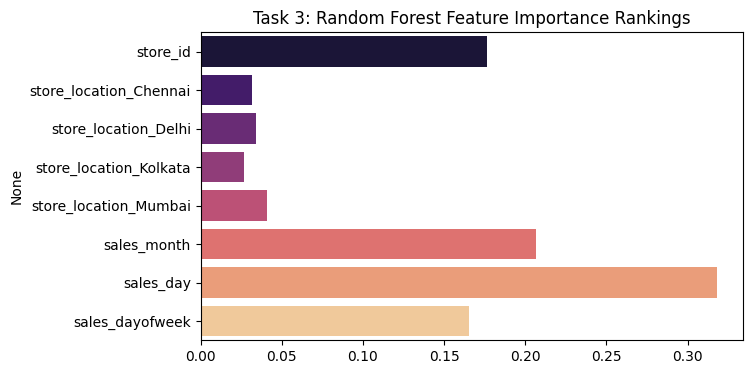

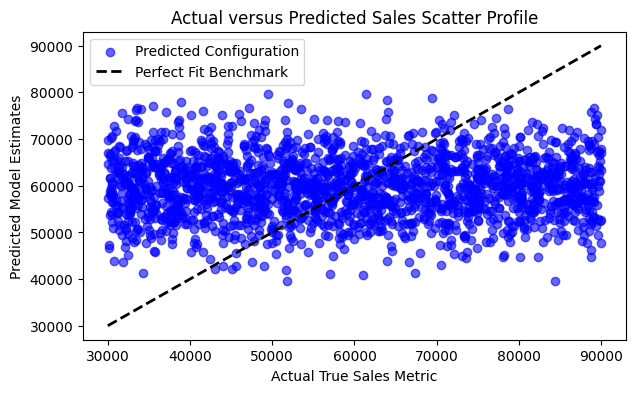


Best Model Hyperparameters Configured: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
✅ Task 3 Completed: Machine Learning execution pipeline functioning correctly!


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load structured dataset
df_ml = pd.read_csv('cleaned_sales_data.csv')
df_ml['date_recorded'] = pd.to_datetime(df_ml['date_recorded'])

# 1 & 2. Feature Engineering: Extract date components
df_ml['sales_month'] = df_ml['date_recorded'].dt.month
df_ml['sales_day'] = df_ml['date_recorded'].dt.day
df_ml['sales_dayofweek'] = df_ml['date_recorded'].dt.dayofweek

# Isolate feature framework (X) and goal targets (y)
X = df_ml.drop(columns=['daily_sales', 'date_recorded'])
y = df_ml['daily_sales']

# 4. Standard train/test operational split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model 1: Linear Regression (Baseline Model Pipeline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 6. Model 2: Random Forest Regressor (Tree-based Complex Pipeline)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 7. Computation of Evaluation Metrics
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = get_metrics(y_test, lr_preds)
rf_mae, rf_rmse, rf_r2 = get_metrics(y_test, rf_preds)

# Formatting structural Performance Table
metrics_df = pd.DataFrame({
    'Performance Metric': ['MAE', 'RMSE', 'R-squared (R2)'],
    'Linear Regression': [lr_mae, lr_rmse, lr_r2],
    'Random Forest Regressor': [rf_mae, rf_rmse, rf_r2]
})
print("\n--- Model Performance Comparison Matrix ---")
print(metrics_df)

# 8. Chart Feature Importance rankings
plt.figure(figsize=(7, 4))
sns.barplot(x=rf_model.feature_importances_, y=X.columns, hue=X.columns, palette='magma', legend=False) # Fix for FutureWarning
plt.title("Task 3: Random Forest Feature Importance Rankings")
plt.show()

# 9. Actual vs Predicted Values Plot
plt.figure(figsize=(7, 4))
plt.scatter(y_test, rf_preds, color='blue', alpha=0.6, label='Predicted Configuration')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit Benchmark')
plt.xlabel('Actual True Sales Metric')
plt.ylabel('Predicted Model Estimates')
plt.title('Actual versus Predicted Sales Scatter Profile')
plt.legend()
plt.show()

# 10. Hyperparameter Optimization Framework via GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"\nBest Model Hyperparameters Configured: {grid_search.best_params_}")
print("✅ Task 3 Completed: Machine Learning execution pipeline functioning correctly!")
